# Import Necessary Libraries


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Data Analysis

In [2]:
df = pd.read_csv("ds_salaries.csv")

In [3]:
df.drop(columns=['Unnamed: 0','salary', 'salary_currency'], inplace=True)

In [82]:
def categorical_percentage(df):
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        print(f"Column: {col}")
        print(df[col].value_counts(normalize=True) * 100)
        print("-" * 50)

In [83]:
categorical_percentage(df)

Column: experience_level
experience_level
SE    46.128501
MI    35.090610
EN    14.497529
EX     4.283361
Name: proportion, dtype: float64
--------------------------------------------------
Column: employment_type
employment_type
FT    96.869852
PT     1.647446
CT     0.823723
FL     0.658979
Name: proportion, dtype: float64
--------------------------------------------------
Column: job_title
job_title
Data Scientist                              23.558484
Data Engineer                               21.746293
Data Analyst                                15.980231
Machine Learning Engineer                    6.754530
Research Scientist                           2.635914
Data Science Manager                         1.976936
Data Architect                               1.812191
Machine Learning Scientist                   1.317957
Big Data Engineer                            1.317957
Director of Data Science                     1.153213
AI Scientist                                 1.153213


# Data Visualisation

In [84]:
def visualize_categorical_distribution(df):
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        plt.figure(figsize=(6, 3))  # Reduce figure size
        value_counts = df[col].value_counts(normalize=True) * 100 
        if len(value_counts) > 10:
            value_counts = value_counts[:10]  
        sns.barplot(x=value_counts.values, y=value_counts.index, hue=value_counts.index, palette="viridis", legend=False)
        plt.xlabel("Percentage", fontsize=10)  # Reduce font size
        plt.ylabel(col, fontsize=10)
        plt.title(f"Distribution of {col}", fontsize=12)
        plt.xlim(0, value_counts.max() + 5) 
        plt.grid(axis="x", linestyle="--", alpha=0.5)
        for index, value in enumerate(value_counts.values):
            plt.text(value + 1, index, f"{value:.1f}%", va="center", fontsize=8)  # Reduce text size
        plt.show()

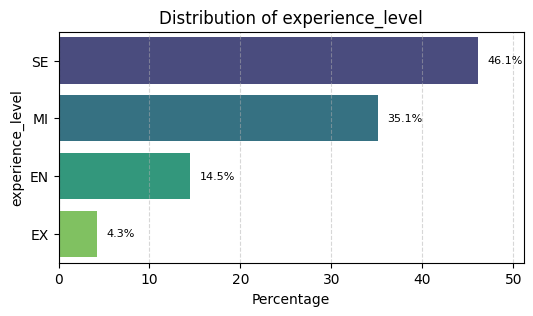

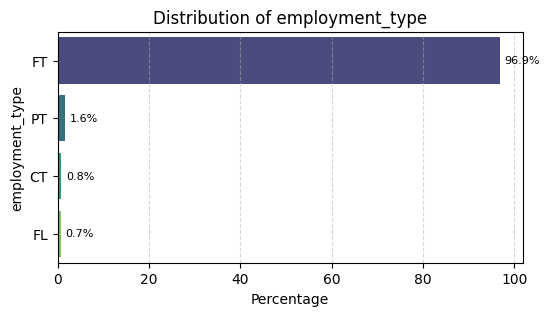

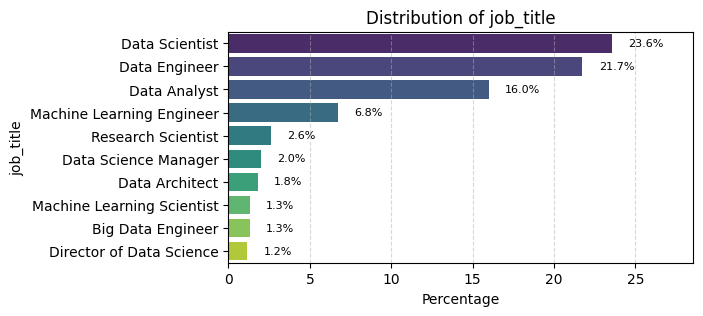

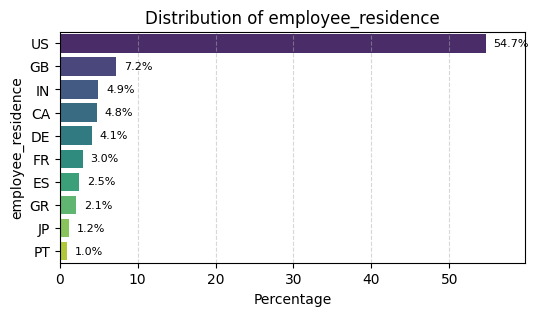

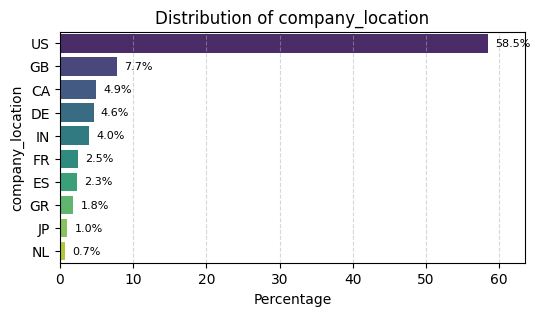

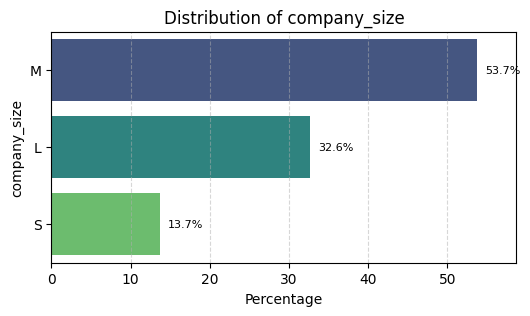

In [85]:
visualize_categorical_distribution(df)

In [86]:
def visualize_unique_value_counts(df, cols):
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(6, 3))
            value_counts = df[col].value_counts()
            percentages = (value_counts / value_counts.sum()) * 100  
            sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, hue=value_counts.index.astype(str), palette="viridis", legend=False)

            plt.xlabel(col, fontsize=10)
            plt.ylabel("Count", fontsize=12)
            plt.title(f"Unique Value Counts of {col}", fontsize=14)
            plt.grid(axis="y", linestyle="--", alpha=0.5)
            for index, (count, percent) in enumerate(zip(value_counts.values, percentages.values)):
                plt.text(index, count + 1, f"{count} ({percent:.1f}%)", ha="center", fontsize=10)
            plt.show()

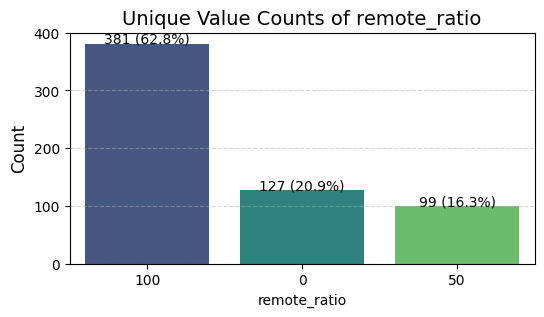

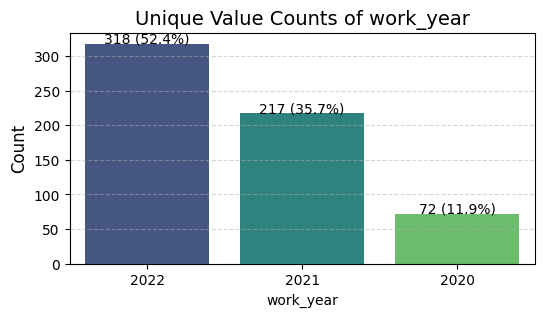

In [87]:
visualize_unique_value_counts(df, ["remote_ratio", "work_year"])

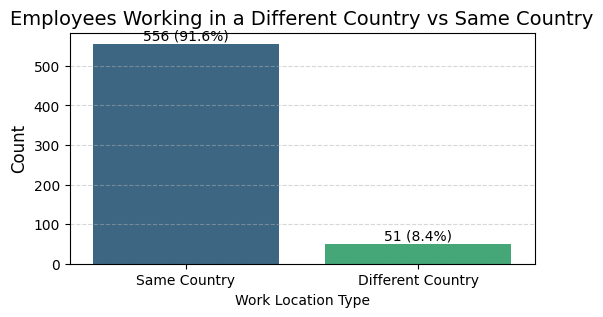

In [88]:
df["different_country"] = df["employee_residence"] != df["company_location"]
value_counts = df["different_country"].value_counts()
percentages = (value_counts / value_counts.sum()) * 100 
plt.figure(figsize=(6, 3))
sns.barplot(x=value_counts.index.map({False: "Same Country", True: "Different Country"}), 
            y=value_counts.values, 
            hue=value_counts.index.map({False: "Same Country", True: "Different Country"}), 
            palette="viridis", legend=False)
plt.xlabel("Work Location Type", fontsize=10)
plt.ylabel("Count", fontsize=12)
plt.title("Employees Working in a Different Country vs Same Country", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
for index, (count, percent) in enumerate(zip(value_counts.values, percentages.values)):
    plt.text(index, count + 10, f"{count} ({percent:.1f}%)", ha="center", fontsize=10)
plt.show()
df.drop(columns=["different_country"], inplace=True)

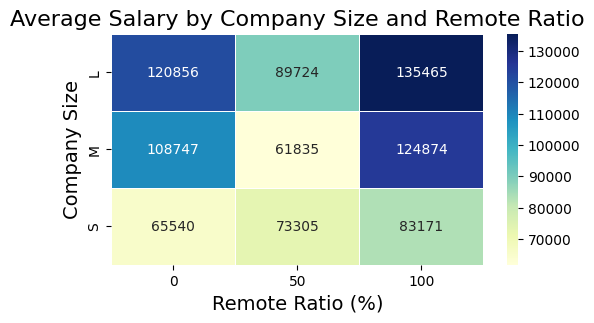

In [89]:
heatmap_data = df.pivot_table(values='salary_in_usd', index='company_size', columns='remote_ratio', aggfunc='mean')

plt.figure(figsize=(6, 3))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title('Average Salary by Company Size and Remote Ratio', fontsize=16)
plt.xlabel('Remote Ratio (%)', fontsize=14)
plt.ylabel('Company Size', fontsize=14)
plt.show()

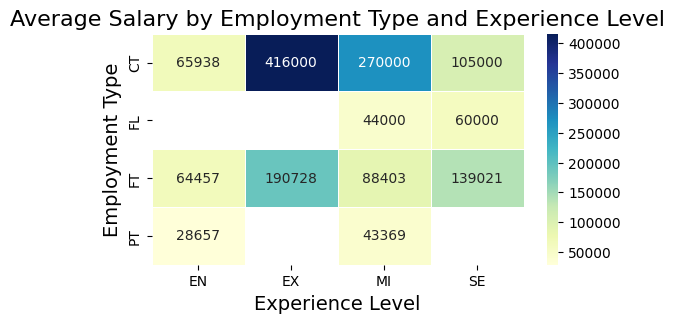

In [90]:
salary_by_employment_experience = df.groupby(['employment_type', 'experience_level'])['salary_in_usd'].mean().unstack()

plt.figure(figsize=(6, 3))
sns.heatmap(salary_by_employment_experience, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title('Average Salary by Employment Type and Experience Level', fontsize=16)
plt.xlabel('Experience Level', fontsize=14)
plt.ylabel('Employment Type', fontsize=14)
plt.show()

# Data Transformation

In [91]:
job_groups = {
    "Data Science & Analytics": [
        "Data Scientist",
        "Lead Data Scientist",
        "Data Analyst",
        "Lead Data Analyst",
        "Business Data Analyst",
        "BI Data Analyst",
        "Product Data Analyst",
        "Marketing Data Analyst",
        "Financial Data Analyst",
        "Finance Data Analyst",
    ],
    "Machine Learning & AI": [
        "Machine Learning Scientist",
        "Machine Learning Engineer",
        "ML Engineer",
        "Machine Learning Developer",
        "Applied Machine Learning Scientist",
        "AI Scientist",
        "NLP Engineer",
        "Computer Vision Engineer",
        "Computer Vision Software Engineer",
        "3D Computer Vision Researcher",
    ],
    "Data Engineering": [
        "Data Engineer",
        "Lead Data Engineer",
        "Big Data Engineer",
        "Cloud Data Engineer",
        "Data Science Engineer",
        "Principal Data Engineer",
        "Big Data Architect",
        "Data Architect",
        "ETL Developer",
        "Machine Learning Infrastructure Engineer",
    ],
    "Leadership & Strategy": [
        "Director of Data Science",
        "Director of Data Engineering",
        "Head of Data",
        "Head of Data Science",
        "Head of Machine Learning",
        "Principal Data Scientist",
        "Staff Data Scientist",
        "Data Science Manager",
        "Data Engineering Manager",
        "Machine Learning Manager",
        
    ],
    "Specialized & Research Roles": [
        "Research Scientist",
        "Applied Data Scientist",
        "Data Science Consultant",
        "Data Specialist",
        "Data Analytics Manager",
        "Data Analytics Lead",
        "Analytics Engineer",
        "Data Analytics Engineer",
        "Principal Data Analyst",
        "Lead Machine Learning Engineer",
    ],
}
def categorize_job_title(job_title):
    for category, titles in job_groups.items():
        if job_title in titles:
            return category
    return 'Other'
df['job_category'] = df['job_title'].apply(categorize_job_title)
df.drop(columns=["job_title"], inplace=True)

In [92]:
df["job_category"].unique()

array(['Data Science & Analytics', 'Machine Learning & AI',
       'Data Engineering', 'Specialized & Research Roles',
       'Leadership & Strategy'], dtype=object)

In [93]:
df.head()

,work_year,experience_level,employment_type,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category
0,2020,MI,FT,79833,DE,0,DE,L,Data Science & Analytics
1,2020,SE,FT,260000,JP,0,JP,S,Machine Learning & AI
2,2020,SE,FT,109024,GB,50,GB,M,Data Engineering
3,2020,MI,FT,20000,HN,0,HN,S,Data Science & Analytics
4,2020,SE,FT,150000,US,50,US,L,Machine Learning & AI


In [94]:
def convert_iso2_to_iso3(iso2_code):
    try:
        return pycountry.countries.get(alpha_2=iso2_code).alpha_3
    except AttributeError:
        return None  
df["employee_residence"] = df["employee_residence"].apply(convert_iso2_to_iso3)
df["company_location"] = df["company_location"].apply(convert_iso2_to_iso3)

In [95]:
gdp_df = pd.read_csv("GDP.csv", skiprows=4) # from https://data.worldbank.org data 1960 - 2023
gdp_df.drop(columns=["Country Name", "Indicator Name", "Indicator Code", "Unnamed: 68"], errors="ignore", inplace=True)

In [96]:
df.head()

,work_year,experience_level,employment_type,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category
0,2020,MI,FT,79833,DEU,0,DEU,L,Data Science & Analytics
1,2020,SE,FT,260000,JPN,0,JPN,S,Machine Learning & AI
2,2020,SE,FT,109024,GBR,50,GBR,M,Data Engineering
3,2020,MI,FT,20000,HND,0,HND,S,Data Science & Analytics
4,2020,SE,FT,150000,USA,50,USA,L,Machine Learning & AI


In [97]:
def get_gdp(row, location_col):
    country_code = row[location_col]
    year = str(row["work_year"])  
    if country_code in gdp_df["Country Code"].values and year in gdp_df.columns:
        return gdp_df.loc[gdp_df["Country Code"] == country_code, year].values[0]
    return None  
df["employee_residence"] = df.apply(lambda row: get_gdp(row, "employee_residence"), axis=1)
df["company_location"] = df.apply(lambda row: get_gdp(row, "company_location"), axis=1)

In [98]:
def apply_one_hot_encoding(df, columns):
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    df = df.copy() 
    for column in columns:
        encoded_values = encoder.fit_transform(df[[column]])
        encoded_df = pd.DataFrame(encoded_values, 
                                  columns=[f"{column}_{category}" for category in encoder.categories_[0]],
                                  index=df.index) 
        df = df.drop(column, axis=1)
        df = pd.concat([df, encoded_df], axis=1)
    return df
columns_to_encode = ['remote_ratio', 'work_year', 'experience_level', 'employment_type', 'company_size', 'job_category']
df = apply_one_hot_encoding(df, columns_to_encode)

In [99]:
df.head()

,salary_in_usd,employee_residence,company_location,remote_ratio_0,remote_ratio_50,remote_ratio_100,work_year_2020,work_year_2021,work_year_2022,experience_level_EN,...,employment_type_FT,employment_type_PT,company_size_L,company_size_M,company_size_S,job_category_Data Engineering,job_category_Data Science & Analytics,job_category_Leadership & Strategy,job_category_Machine Learning & AI,job_category_Specialized & Research Roles
0,79833,47379.765195,47379.765195,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,260000,40040.765506,40040.765506,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,109024,40201.681242,40201.681242,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,20000,2307.614943,2307.614943,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,150000,64411.373178,64411.373178,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Feature Scaling

In [100]:
log_columns = ["salary_in_usd", "employee_residence", "company_location"]
df[log_columns] = df[log_columns].apply(np.log)
scaler = MinMaxScaler()
df[:] = scaler.fit_transform(df)

In [101]:
df.head()

,salary_in_usd,employee_residence,company_location,remote_ratio_0,remote_ratio_50,remote_ratio_100,work_year_2020,work_year_2021,work_year_2022,experience_level_EN,...,employment_type_FT,employment_type_PT,company_size_L,company_size_M,company_size_S,job_category_Data Engineering,job_category_Data Science & Analytics,job_category_Leadership & Strategy,job_category_Machine Learning & AI,job_category_Specialized & Research Roles
0,0.622742,0.776887,0.776887,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.843588,0.740695,0.740695,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.681030,0.741558,0.741558,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.363841,0.127010,0.127010,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.740708,0.842928,0.842928,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Making Model 

In [102]:
X = df.drop(columns=['salary_in_usd'])  
y = df['salary_in_usd'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

MAE: 0.06292026881854358
Mean Squared Error: 0.00948746902997008


In [106]:
# MAE: 28905.190522493598
# Mean Squared Error: 1882828336.762651
# this is the results without scale

# Improving Model Performance

In [107]:
# param_grid = {
#     'n_estimators': [100, 200, 300, 400, 500],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['auto', 'sqrt', 'log2'],
#     'bootstrap': [True, False]
# }
# random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)
# random_search.fit(X_train, y_train)
# best_params = random_search.best_params_
# best_model = random_search.best_estimator_
# print(f"Best Parameters: {best_params}")

In [108]:
model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    bootstrap=False
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

MAE: 0.06067122746652751
Mean Squared Error: 0.008444604161018679


In [109]:
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)

                                      Feature  Importance
0                          employee_residence    0.345693
1                            company_location    0.247638
11                        experience_level_SE    0.074296
8                         experience_level_EN    0.070828
10                        experience_level_MI    0.032321
9                         experience_level_EX    0.028642
18                             company_size_S    0.027493
21         job_category_Leadership & Strategy    0.024303
7                              work_year_2022    0.022351
15                         employment_type_PT    0.021117
20      job_category_Data Science & Analytics    0.017154
3                             remote_ratio_50    0.010963
6                              work_year_2021    0.010256
14                         employment_type_FT    0.008937
16                             company_size_L    0.008813
17                             company_size_M    0.008394
19            

In [110]:
# import optuna
# def objective(trial):
#     # Suggest hyperparameters
#     n_estimators = trial.suggest_int("n_estimators", 50, 500, step=50)
#     max_depth = trial.suggest_int("max_depth", 5, 30, step=5)
#     min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
#     min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
#     max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
#     bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    
#     # Train model
#     model = RandomForestRegressor(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         min_samples_split=min_samples_split,
#         min_samples_leaf=min_samples_leaf,
#         max_features=max_features,
#         bootstrap=bootstrap,
#         random_state=42
#     )
    
#     # Evaluate using cross-validation
#     scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
#     return -np.mean(scores)  # Minimize MAE

# # Run Optuna optimization
# study = optuna.create_study(direction="minimize")  # We minimize MAE
# study.optimize(objective, n_trials=50)  # Run 50 trials

# # Get best hyperparameters
# best_params = study.best_params
# print("Best Parameters:", best_params)

In [111]:
# model = RandomForestRegressor(**best_params, random_state=42)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
# print("R2 Score:", r2_score(y_test, y_pred))